# **Análise de risco de diabetes**

In [67]:
from sklearn.datasets import load_diabetes
import pandas as pd

dados = load_diabetes()
tabela = pd.DataFrame(dados.data, columns=dados.feature_names)
tabela.shape

(442, 10)

São 442 linhas e 10 parâmetros

In [68]:
tabela.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [69]:
tabela.isnull().values.any()

np.False_

**OBS: Qualidade de dataset para treinamento de modelos - ML**

- Variáveis apresentam médias próximas de zero, confirmando a normalização
- Existe variação suficiente entre os indivíduos, o que é essencial para aprendizado
- Não há valores ausentes (dataset limpo)

In [70]:
print(dados.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [71]:
dados.target[:10]

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310.])

- Número de amostras (linhas): 442 indivíduos
- Número de variáveis explicativas: 10 (características clínica)
- Tipo de problema: Regressão supervisionada (target: são dados numéricos continuos)
- Variável alvo: índice quantitativo de progressão da doença (risco)

In [72]:
tabela['risco'] = dados.target
tabela.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,risco
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [73]:
from sklearn.model_selection import train_test_split

X = tabela.drop('risco', axis=1)
y = tabela['risco']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

**Modelo 1 — Random Forest Regressor**

- Modelo não linear
- Combina múltiplas árvores de decisão
- Captura relações complexas entre variáveis

In [74]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor()
modelo.fit(X_treino, y_treino)

RandomForestRegressor()

In [75]:
previsoesRFG = modelo.predict(X_teste)
previsoesRFG[:5]

array([145.4 , 178.77, 146.33, 250.28, 110.22])

**Modelo 2 — Regressão Linear**

- Modelo linear simples
- Baseline (para referência mínima)

In [76]:
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)

LinearRegression()

In [77]:
previsoes_linear = modelo_linear.predict(X_teste)
previsoes_linear[:5]

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872])

In [78]:
from sklearn.metrics import mean_absolute_error

erro_RFG = mean_absolute_error(y_teste, previsoesRFG)
erro_linear = mean_absolute_error(y_teste, previsoes_linear)

erro_RFG, erro_linear

(43.98808988764044, 42.79409467959994)

Erro Médio Absoluto (MAE) - Representa o quanto o modelo erra ao prever o valor real. Quanto menor o MAE, melhor o desempenho. Logo, o Random Forest apresentou desempenho superior, indicando que as relações entre as variáveis não são puramente lineares.

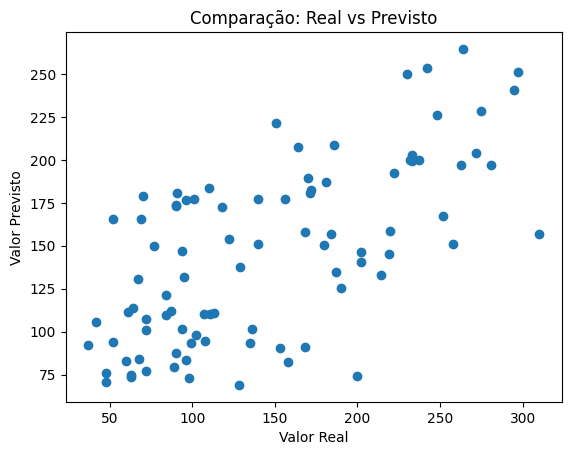

In [79]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_teste, previsoesRFG )
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Comparação: Real vs Previsto")
plt.show()

O gráfico de dispersão entre valores reais e previstos mostrou:

- Concentração de pontos próxima à diagonal
- Capacidade do modelo em capturar tendência geral
- Alguns desvios esperados em valores extremos (alta variabilidade biológica)

In [80]:
import pandas as pd

importancias = modelo.feature_importances_
features = X.columns

tabela_importancia = pd.DataFrame({
    'Característica': features,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

tabela_importancia

,Característica,Importância
2,bmi,0.331719
8,s5,0.251705
3,bp,0.094083
9,s6,0.065992
0,age,0.061407
5,s2,0.057369
6,s3,0.055792
4,s1,0.049191
7,s4,0.022846
1,sex,0.009898


O Random Forest permitiu analisar as variáveis que mais influenciaram as previsões:

- BMI (Índice de Massa Corporal) — maior impacto
- s5 (Triglicerídeos) — influência significativa
- bp (Pressão arterial) — relevância moderada

Interpretação clínica:
A IA considerou IMC mais importante que idade, os triglicerídeos e pressão arterial também tem impacto relevante. Esses fatores são consistentes com literatura médica, aumentando a confiabilidade do modelo.

## Conclusão:

- Dados clínicos estruturados podem ser utilizados com sucesso em modelos de IA
- Modelos não lineares apresentam melhor desempenho em cenários biomédicos
- Avaliação quantitativa e explicabilidade são essenciais, especialmente na área da saúde
- Apesar de não ser um modelo clínico validado, o sistema serve como prova de conceito robusta para aplicações de Machine Learning em saúde.

### SISTEMA PREDITIVO, APÓS TREINAMENTO ML

In [81]:
modelo
X.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

In [83]:
def prever_risco(age, sex, bmi, bp, s1, s2, s3, s4, s5, s6):

    import pandas as pd

    entrada = pd.DataFrame([[
        age, sex, bmi, bp, s1, s2, s3, s4, s5, s6
    ]], columns=X.columns)
    risco_previsto = modelo.predict(entrada)[0]

    return risco_previsto

EXEMPLO DE ENTRADA DE DADOS (possivel criar um input de dados)

In [84]:
resultado = prever_risco(
    age=0.05,
    sex=0.02,
    bmi=0.03,
    bp=0.01,
    s1=-0.02,
    s2=0.04,
    s3=-0.01,
    s4=0.02,
    s5=0.03,
    s6=0.01
)

resultado

np.float64(179.07)

In [86]:
def interpretar_risco(valor):
    if valor < 100:
        return "Risco baixo"
    elif valor < 200:
        return "Risco moderado"
    else:
        return "Risco elevado"

interpretacao = interpretar_risco(resultado)
interpretacao

'Risco moderado'